# Trabajo Práctico Final - Predicción de Riesgo en Salud Materna
**Materia:** Taller de Lenguajes de Programación III - Python para Ciencia de Datos

**Dataset:** Maternal Health Risk Data (UCI Machine Learning Repository)

**Objetivo:** Predecir el nivel de riesgo (bajo, medio, alto) de una persona embarazada en base a signos vitales, para asistir en la priorización de atención médica.

**Variables del dataset:**
- `Age`: edad de la persona
- `SystolicBP`: presión arterial sistólica
- `DiastolicBP`: presión arterial diastólica
- `BS`: nivel de glucosa en sangre (Blood Sugar)
- `BodyTemp`: temperatura corporal
- `HeartRate`: frecuencia cardíaca
- `RiskLevel`: variable objetivo (low risk / mid risk / high risk)

## 1. Carga y exploración inicial del dataset

In [1]:
import pandas as pd 

In [2]:
#leemos el dataset
df = pd.read_csv("maternal-health-risk.csv")
df.tail()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
1009,22,120,60,15.0,98.0,80,high risk
1010,55,120,90,18.0,98.0,60,high risk
1011,35,85,60,19.0,98.0,86,high risk
1012,43,120,90,18.0,98.0,70,high risk
1013,32,120,65,6.0,101.0,76,mid risk


In [3]:
df.info()
#info general del dataset, vemos que no hay datos nulos

<class 'pandas.DataFrame'>
RangeIndex: 1014 entries, 0 to 1013
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          1014 non-null   int64  
 1   SystolicBP   1014 non-null   int64  
 2   DiastolicBP  1014 non-null   int64  
 3   BS           1014 non-null   float64
 4   BodyTemp     1014 non-null   float64
 5   HeartRate    1014 non-null   int64  
 6   RiskLevel    1014 non-null   str    
dtypes: float64(2), int64(4), str(1)
memory usage: 55.6 KB


In [4]:
#esto para ver los datos duplicados
df.duplicated().sum()
#podemos observar 562 datos duplicados

np.int64(562)

## 2. Preprocesamiento: limpieza de duplicados
Encontramos 562 filas duplicadas. Esto probablemente se deba a que el dataset original junta registros repetidos de mediciones similares. Las eliminamos para que no sesguen el entrenamiento del modelo (si una combinación de valores aparece 50 veces solo porque se cargó mal, el árbol le daría más peso del que debería).

In [ ]:
#limpiamos los duplicados
# drop_duplicates() los borra, y reset_index() acomoda los números de las filas para que no queden huecos
df_limpio = df.drop_duplicates().reset_index(drop=True) #podriamos usar inplace=true para sobreescribir el df original y ahorrar espacio, pero, en este caso me parece mas limpio otrabajar asi

In [ ]:
df_limpio.duplicated().sum() #aca visualizamos el dataset limpio, y lo guardamos en una nueva variable llamada df_limoio 

np.int64(0)

In [7]:
df.shape #visualizamos cuantas filas y columnas tiene el dataset

(1014, 7)

In [8]:
df_limpio.shape #visualizamos cuantas filas y columnas tiene el nuevo dataset

(452, 7)

In [9]:
df_limpio.columns #buscamos nuestra variable objetivo, en este caso, tomamos RiskLevel que es lo que nos interesa, medir el nivel de riesgo

Index(['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate',
       'RiskLevel'],
      dtype='str')

## 3. Análisis Exploratorio de Datos (EDA)
Antes de tocar el modelo, exploramos visualmente las variables para entender su distribución, detectar valores atípicos (outliers) y ver si existe relación entre las variables y el nivel de riesgo.

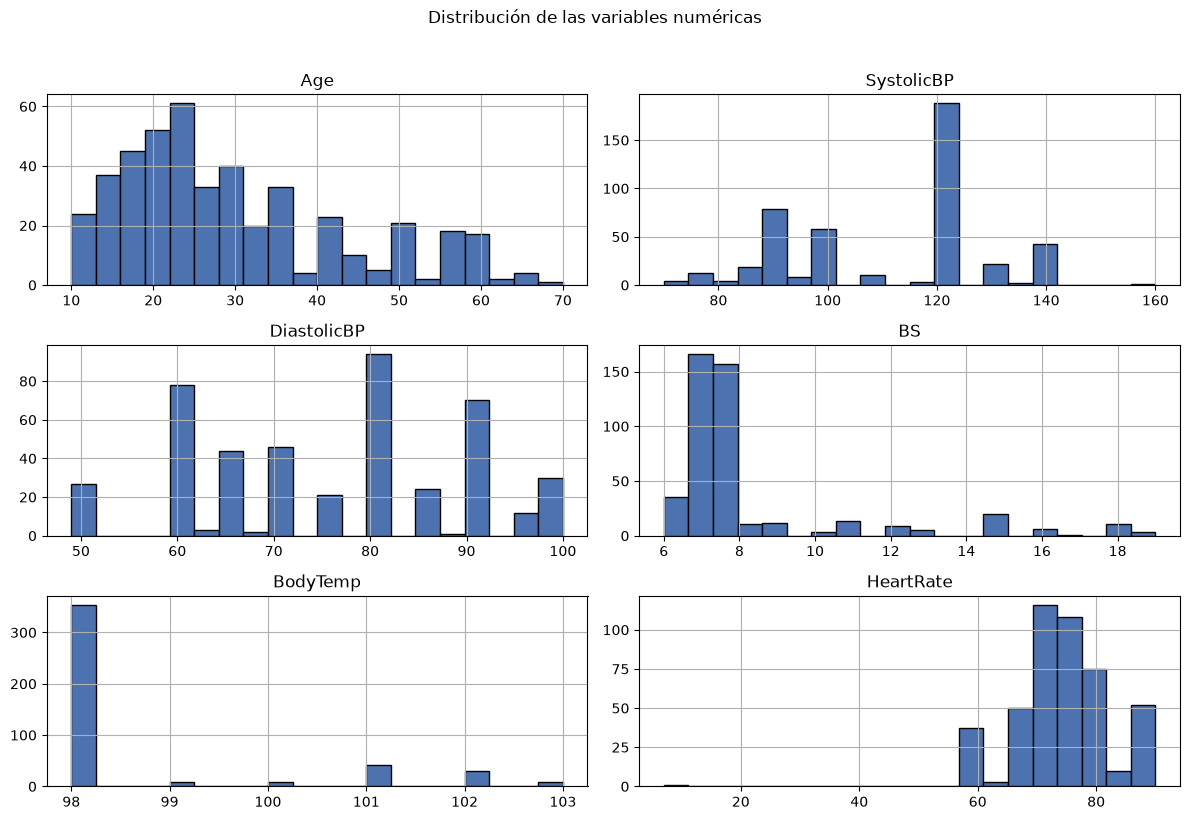

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

#df_prueba.hist(edgecolor="black", figsize=(10,10))  #de manera más simple
#plt.suptitle("distribucion de variables")


# distribución de cada variable numérica
df_limpio.hist(figsize=(12, 8), bins=20, color='#4C72B0', edgecolor='black')
plt.suptitle('Distribución de las variables numéricas', y=1.02)
plt.tight_layout()
plt.show()

**Lectura rápida:** La mayoría de las variables tienen una distribución razonable, pero `HeartRate` muestra una barra aislada cerca de 0, lo cual no tiene sentido fisiológico (nadie tiene una frecuencia cardíaca de 7 latidos por minuto estando con vida). Eso lo vamos a tratar como outlier en la siguiente sección.

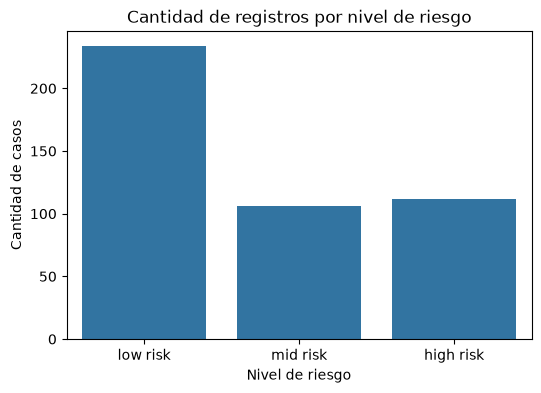

In [ ]:
# cantidad de casos por nivel de riesgo
plt.figure(figsize=(6, 4))
sns.countplot(data=df_limpio, x='RiskLevel', order=['low risk', 'mid risk', 'high risk'])
plt.title('Cantidad de registros por nivel de riesgo')
plt.xlabel('Nivel de riesgo')
plt.ylabel('Cantidad de casos')
plt.show()

Las clases están medianamente desbalanceadas (hay más casos de riesgo bajo que de riesgo medio o alto). Esto es importante: si en algún momento la `accuracy` nos da muy alta, hay que revisar con matriz de confusión que no sea solo porque el modelo predice siempre 'riesgo bajo'.

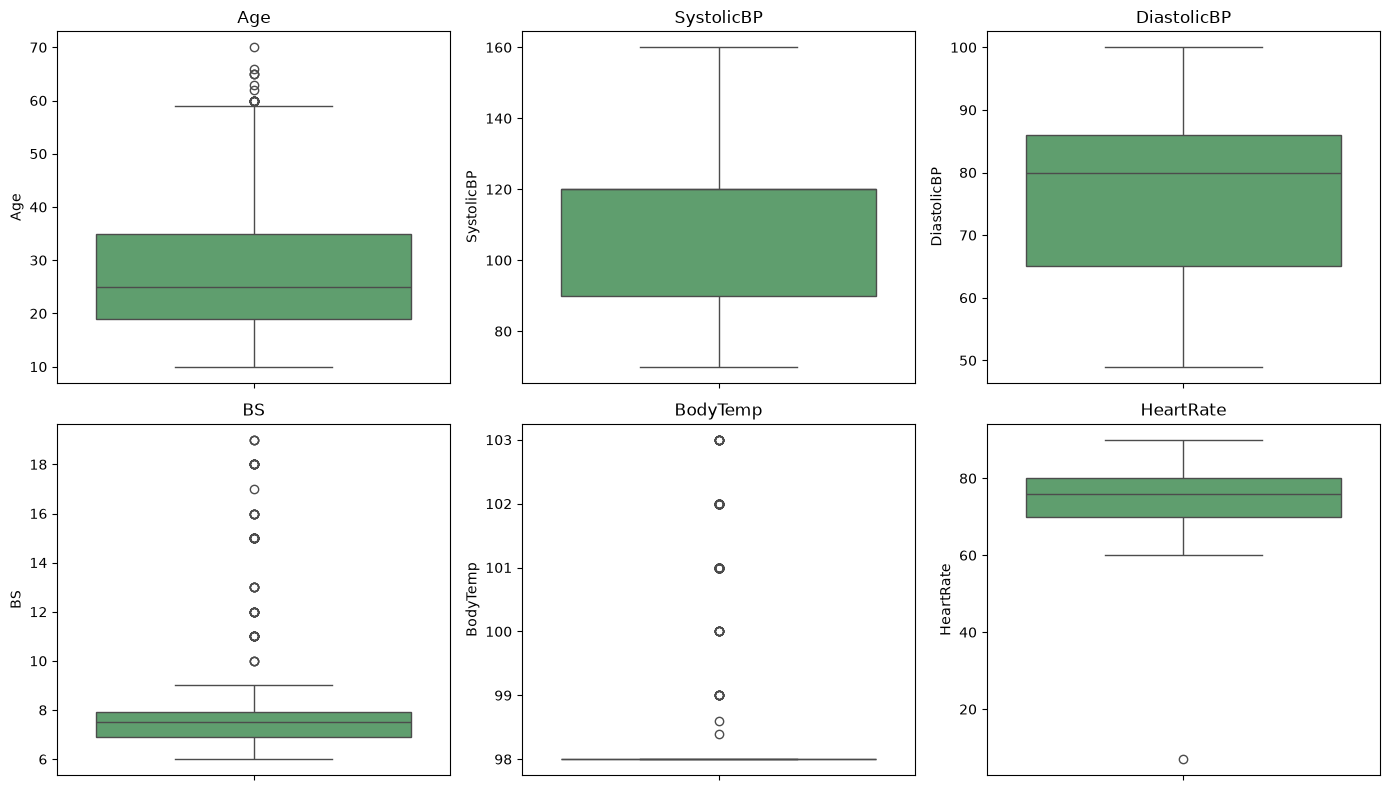

In [12]:
# boxplots para detectar outliers en cada variable
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
variables = ['Age', 'SystolicBP', 'DiastolicBP', 'BS', 'BodyTemp', 'HeartRate']

for ax, var in zip(axes.flatten(), variables):
    sns.boxplot(data=df_limpio, y=var, ax=ax, color='#55A868')
    ax.set_title(var)

plt.tight_layout()
plt.show()

En el boxplot de `HeartRate` se nota un punto muy por debajo del resto del grupo: ese es el mismo valor de 7 latidos por minuto que vimos en el histograma. Las otras variables (`BS`, `BodyTemp`) tienen algunos puntos altos, pero son valores fisiológicamente posibles en cuadros de riesgo alto (glucosa o temperatura elevada), así que no los vamos a eliminar, son información real y relevante para el modelo.

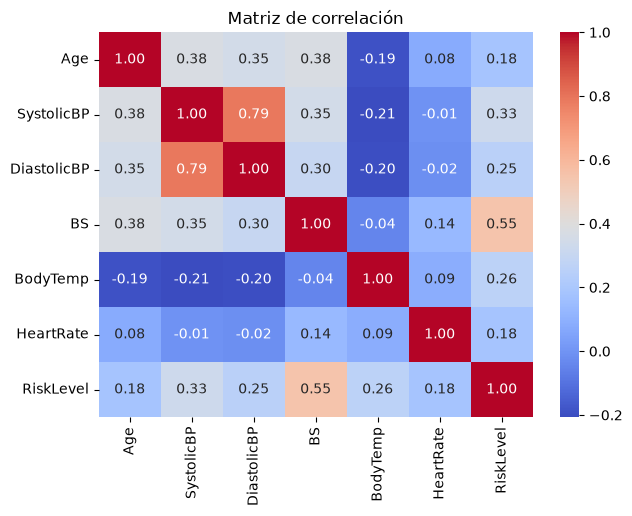

In [13]:
# relación entre variables y nivel de riesgo (esto nos responde la pregunta: hay correlación?)
df_corr = df_limpio.copy()
df_corr['RiskLevel'] = df_corr['RiskLevel'].map({'low risk': 0, 'mid risk': 1, 'high risk': 2})

plt.figure(figsize=(7, 5))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

`BS` (glucosa) es la variable que más correlación tiene con el nivel de riesgo, seguida por `Age`. Esto tiene sentido clínico: la glucosa alta está asociada a diabetes gestacional, un factor de riesgo importante en el embarazo.

## 4. Tratamiento de outliers
Vimos en el EDA que hay un único registro con `HeartRate = 7`, un valor imposible para una persona con vida. Es un error de carga de datos, no una variable de riesgo real, así que lo eliminamos en vez de dejar que el árbol aprenda una regla rara a partir de un solo dato erróneo.

In [14]:
# vemos cuántos registros están por debajo de un umbral fisiológicamente razonable, que es 30 latido por minutos
df_limpio[df_limpio['HeartRate'] < 30] #esto visualiza un solo registo que no es razonable

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
342,16,120,75,7.9,98.0,7,low risk


In [15]:
# Eliminamos ese registro
df_limpio = df_limpio[df_limpio['HeartRate'] >= 30].reset_index(drop=True) #accedemos al index y borramos ese registro
df_limpio.shape#visualizamos cuantas filas y columnas contieen ahora nuestro dataset

(451, 7)

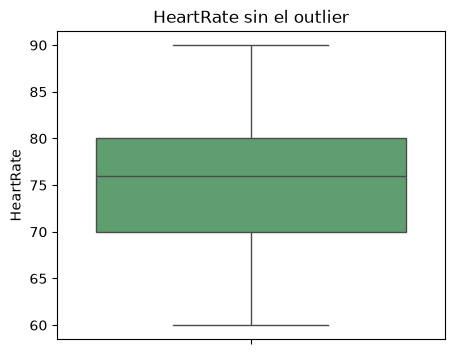

In [16]:
#confirmamos que ya no quedan valores extremos en HeartRate
plt.figure(figsize=(5,4))
sns.boxplot(data=df_limpio, y='HeartRate', color='#55A868')
plt.title('HeartRate sin el outlier')
plt.show()

## 5. Codificación de la variable objetivo
`RiskLevel` es texto (`low risk`, `mid risk`, `high risk`). Los algoritmos de scikit-learn necesitan números, así que la convertimos con un *Label Encoding* manual usando `.map()`.

In [17]:
df_limpio["RiskLevel"].unique() #vemos qu elos niveles de riesgo se dividen en, high low y mid (supongo que alto, bajo y medio)

<StringArray>
['high risk', 'low risk', 'mid risk']
Length: 3, dtype: str

In [18]:
df_limpio["RiskLevel"].map({ #visualizacion de como va a quedar
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2
})



0      2
1      2
2      2
3      2
4      0
      ..
446    1
447    0
448    0
449    1
450    0
Name: RiskLevel, Length: 451, dtype: int64

In [19]:
df_limpio["RiskLevel"] = df_limpio["RiskLevel"].map({ #aca utilizamos map para hacer una Codificación de Etiquetas (Label Encoding), lo que hicimos fue, transformamos el texto en números para que el algoritmo pueda hacer sus cálculos
    "low risk": 0,
    "mid risk": 1,
    "high risk": 2
})
df_limpio.head()

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate,RiskLevel
0,25,130,80,15.0,98.0,86,2
1,35,140,90,13.0,98.0,70,2
2,29,90,70,8.0,100.0,80,2
3,30,140,85,7.0,98.0,70,2
4,35,120,60,6.1,98.0,76,0


## 6. Separación en variables predictoras (X) y variable objetivo (y)

In [20]:
X = df_limpio[["Age", "SystolicBP", "DiastolicBP", "BS", "BodyTemp", "HeartRate"]] #guardamos en una variable X los valores que el modelo va a estudiar 
X

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
0,25,130,80,15.0,98.0,86
1,35,140,90,13.0,98.0,70
2,29,90,70,8.0,100.0,80
3,30,140,85,7.0,98.0,70
4,35,120,60,6.1,98.0,76
...,...,...,...,...,...,...
446,12,100,50,6.4,98.0,70
447,15,100,60,6.0,98.0,80
448,15,100,49,7.6,98.0,77
449,12,100,50,6.0,98.0,70


In [21]:
y = df_limpio[["RiskLevel"]] #guardamos el valor de la variable objetivo, de lo que el modelo tiene que predecir
y

,RiskLevel
0,2
1,2
2,2
3,2
4,0
...,...
446,1
447,0
448,0
449,1


## 7. Estandarización de variables
La consigna pide aplicar estandarización/normalización como parte del preprocesamiento. Es importante aclarar algo para la defensa: **los árboles de decisión son invariantes a la escala**, porque dividen el espacio con reglas tipo `variable <= umbral`, no con distancias. Que `Age` esté en una escala de 10-70 y `BS` en 6-19 no afecta en nada cómo el árbol elige sus cortes.

Aun así, lo mostramos a continuación (con `StandardScaler`) para cumplir con el punto de preprocesamiento y porque es una buena práctica general que sí sería necesaria si en el futuro probamos otro algoritmo (por ejemplo KNN, SVM o regresión logística), donde la escala sí importa.

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_escalado = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X_escalado.describe().round(2)

,Age,SystolicBP,DiastolicBP,BS,BodyTemp,HeartRate
count,451.00,451.00,451.00,451.00,451.00,451.00
mean,0.00,0.00,-0.00,-0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.40,-2.27,-1.92,-0.83,-0.49,-1.87
25%,-0.74,-1.15,-0.76,-0.51,-0.49,-0.54
50%,-0.31,0.53,0.33,-0.30,-0.49,0.25
75%,0.42,0.53,0.84,-0.16,-0.49,0.78
max,2.96,2.77,1.79,3.77,3.05,2.11


Como se ve, todas las variables quedan con media ≈ 0 y desvío ≈ 1. Para el modelo final **no vamos a usar** `X_escalado`, sino el `X` original sin escalar, justamente porque el árbol de decisión no lo necesita y así mantenemos el modelo más simple e interpretable (los splits del árbol quedan en las unidades originales, que son más fáciles de explicar: 'si la glucosa es mayor a 7.5...' en vez de un valor escalado sin significado clínico).

## 8. Separación en entrenamiento/test y primer modelo (baseline)
Entrenamos un primer árbol de decisión **sin restricciones**, para tener un punto de partida con el cual comparar luego las versiones optimizadas (pre-poda y post-poda).

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

modelo_base = DecisionTreeClassifier(random_state=42)
modelo_base.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Usamos `stratify=y` para que la proporción de las 3 clases (bajo/medio/alto) se mantenga igual en train y test, ya que vimos en el EDA que las clases no están balanceadas.

In [24]:
pred_base = modelo_base.predict(X_test)
acc_base = accuracy_score(y_test, pred_base)
print(f'Accuracy modelo base (sin podar): {acc_base:.3f}')

Accuracy modelo base (sin podar): 0.602


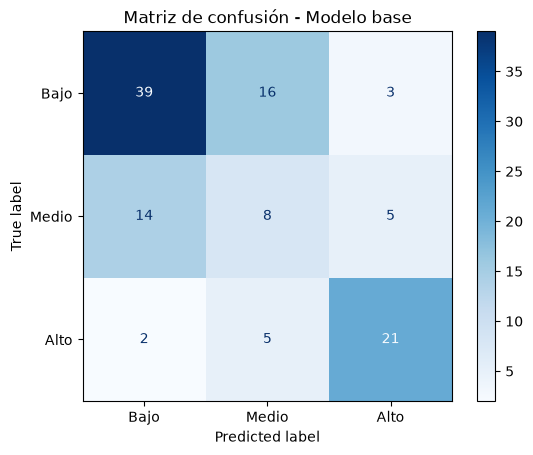

In [25]:
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, y_pred=pred_base,
    display_labels=['Bajo', 'Medio', 'Alto'], cmap='Blues'
)
plt.title('Matriz de confusión - Modelo base')
plt.show()

## 9. Optimización del modelo: control de complejidad (pre-poda)
Un árbol sin restricciones tiende a sobreajustarse (memoriza el set de entrenamiento). Probamos distintos valores de `max_depth` para encontrar un buen equilibrio entre rendimiento en train y en test.

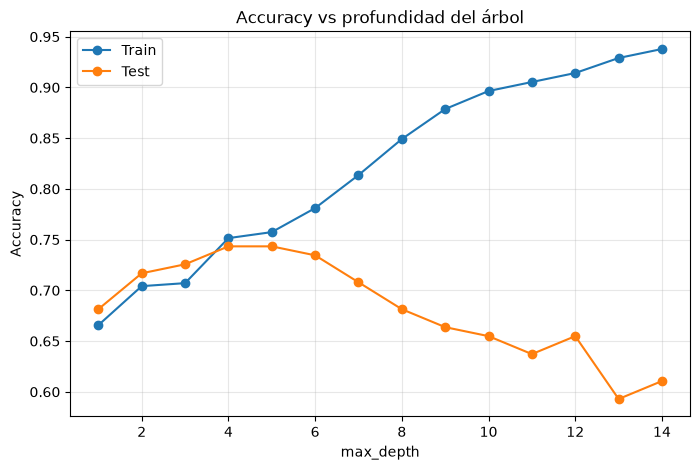

In [26]:
profundidades = range(1, 15)
acc_train_list = []
acc_test_list = []

for prof in profundidades:
    m = DecisionTreeClassifier(max_depth=prof, random_state=42)
    m.fit(X_train, y_train)
    acc_train_list.append(accuracy_score(y_train, m.predict(X_train)))
    acc_test_list.append(accuracy_score(y_test, m.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(profundidades, acc_train_list, marker='o', label='Train')
plt.plot(profundidades, acc_test_list, marker='o', label='Test')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Accuracy vs profundidad del árbol')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Cómo se lee este gráfico:** a medida que aumenta `max_depth`, el accuracy en train sube casi siempre (el árbol memoriza más), pero el de test deja de mejorar (o empeora) a partir de cierto punto: ahí empieza el overfitting. Buscamos el `max_depth` donde el test alcanza su mejor valor antes de que la curva de train se despegue demasiado.

In [27]:
mejor_prof = profundidades[acc_test_list.index(max(acc_test_list))]
print(f'Mejor max_depth según test: {mejor_prof} (accuracy test = {max(acc_test_list):.3f})')

Mejor max_depth según test: 4 (accuracy test = 0.743)


## 10. Modelo final
Entrenamos el modelo definitivo con el `max_depth` óptimo encontrado, y evaluamos con accuracy, reporte de clasificación y matriz de confusión.

In [28]:
model = DecisionTreeClassifier(max_depth=mejor_prof, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc_final = accuracy_score(y_test, y_pred)
print(f'Accuracy modelo final: {acc_final:.3f}')

Accuracy modelo final: 0.743


In [29]:
print(classification_report(y_test, y_pred, target_names=['Bajo', 'Medio', 'Alto']))

              precision    recall  f1-score   support

        Bajo       0.76      0.97      0.85        58
       Medio       0.53      0.30      0.38        27
        Alto       0.83      0.71      0.77        28

    accuracy                           0.74       113
   macro avg       0.71      0.66      0.67       113
weighted avg       0.72      0.74      0.72       113



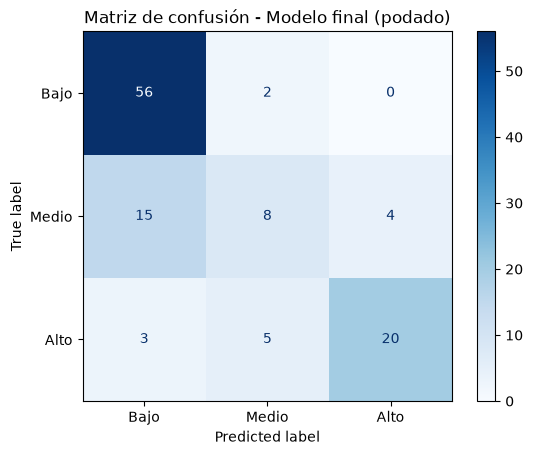

In [30]:
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, y_pred=y_pred,
    display_labels=['Bajo', 'Medio', 'Alto'], cmap='Blues'
)
plt.title('Matriz de confusión - Modelo final (podado)')
plt.show()

**Nota para la defensa:** si `mejor_prof` da un árbol muy poco profundo y el `classification_report` muestra que alguna clase (sobre todo 'riesgo medio', que suele ser la más difícil de distinguir clínicamente) tiene un recall bajo, se puede mencionar como limitación conocida del modelo y como línea futura de mejora (ver sección de próximos pasos: Random Forest, balanceo de clases, etc.).

## 11. Visualización del árbol de decisión final

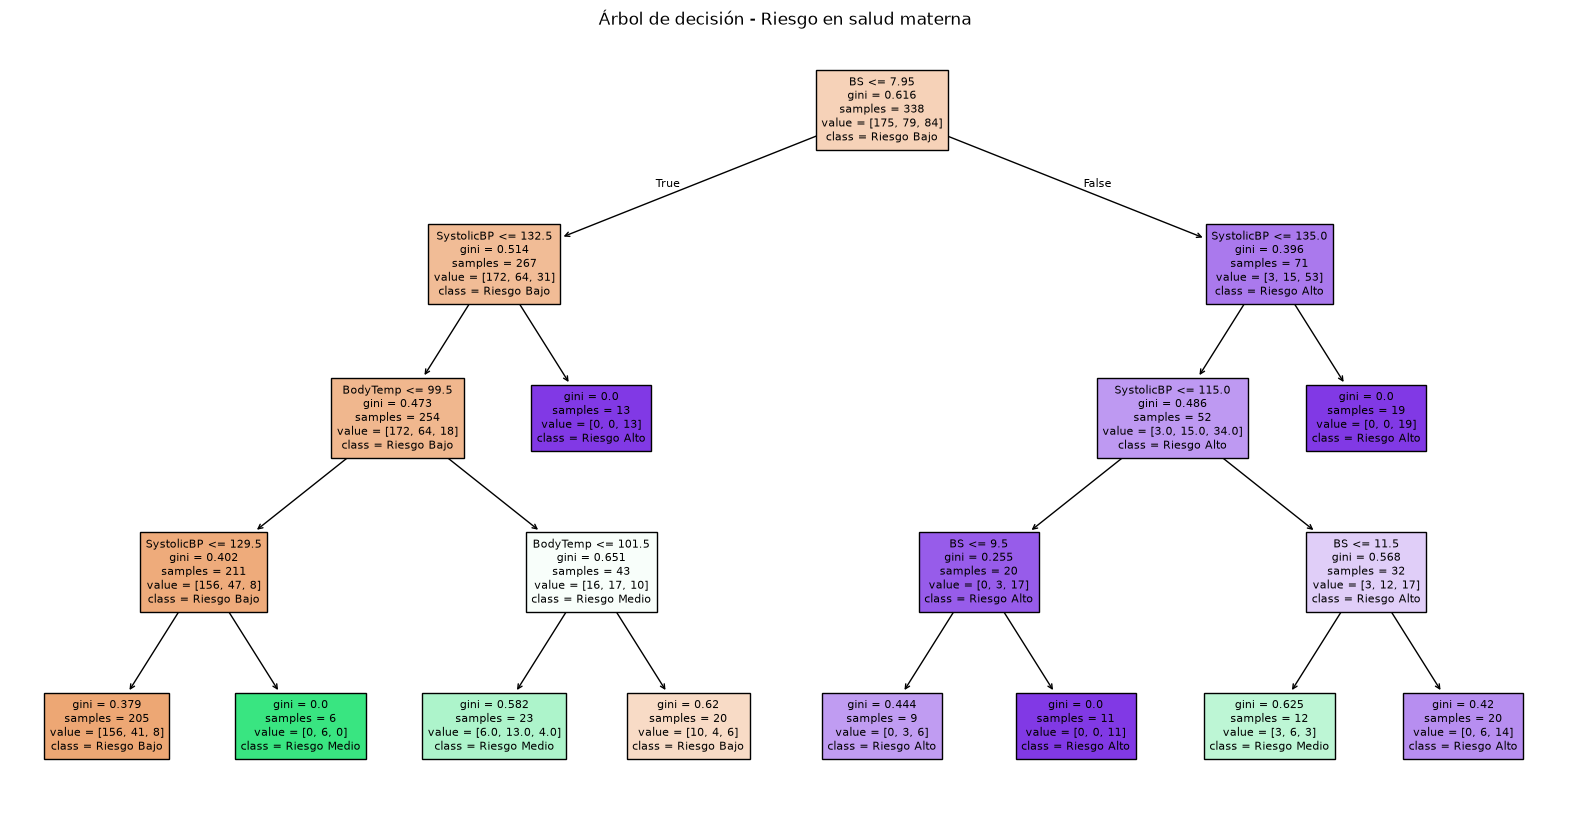

In [31]:
plt.figure(figsize=(20, 10))
from sklearn.tree import plot_tree
plot_tree(model,
          feature_names=X_train.columns,
          fontsize=8,
          class_names=['Riesgo Bajo', 'Riesgo Medio', 'Riesgo Alto'],
          filled=True)
plt.title('Árbol de decisión - Riesgo en salud materna')
plt.show()

C:\Users\IPF-2026\AppData\Local\Temp\ipykernel_16692\3254310572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importancias.values, y=importancias.index, palette='Blues_r')


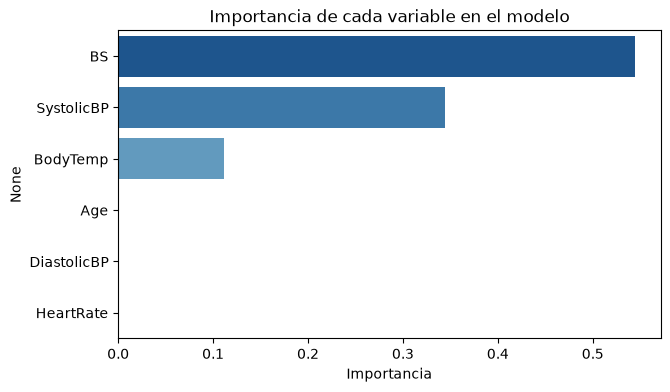

BS             0.544313
SystolicBP     0.344041
BodyTemp       0.111646
Age            0.000000
DiastolicBP    0.000000
HeartRate      0.000000
dtype: float64

In [32]:
# Importancia de cada variable según el modelo
importancias = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(7, 4))
sns.barplot(x=importancias.values, y=importancias.index, palette='Blues_r')
plt.title('Importancia de cada variable en el modelo')
plt.xlabel('Importancia')
plt.show()
importancias

Esto confirma lo que vimos en la matriz de correlación: `BS` (glucosa) es la variable más determinante para el modelo, seguida típicamente por `Age` y la presión arterial.

## 12. Prueba de predicción manual
Probamos el modelo con un caso hipotético. El orden de las columnas debe coincidir exactamente con `X.columns`: `Age, SystolicBP, DiastolicBP, BS, BodyTemp, HeartRate`.

In [33]:
caso_prueba = [[28, 130, 90, 7.5, 98.0, 80]]
prediccion = model.predict(caso_prueba)
etiquetas = {0: 'Riesgo Bajo', 1: 'Riesgo Medio', 2: 'Riesgo Alto'}
print(f'Predicción: {etiquetas[prediccion[0]]}')

Predicción: Riesgo Medio


c:\Users\IPF-2026\Desktop\trabajo-integrador-python\maternal-health-risk\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## 13. Exportación del modelo final
Guardamos el modelo entrenado con `joblib` dentro de la carpeta `models/`, tal como pide la consigna, para que después el backend (FastAPI) lo cargue y lo use en el endpoint `/predict`.

In [34]:
import joblib
import os

os.makedirs('models', exist_ok=True)
joblib.dump(model, 'models/decision_tree_maternal_risk.pkl')
print('Modelo exportado en models/decision_tree_maternal_risk.pkl')

Modelo exportado en models/decision_tree_maternal_risk.pkl


In [35]:
# Verificación rápida: cargamos el modelo guardado y probamos que prediga igual
modelo_cargado = joblib.load('models/decision_tree_maternal_risk.pkl')
modelo_cargado.predict(caso_prueba)

c:\Users\IPF-2026\Desktop\trabajo-integrador-python\maternal-health-risk\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


array([1])

## Conclusión
Se desarrolló un modelo de árbol de decisión para clasificar el nivel de riesgo en salud materna a partir de signos vitales. El preprocesamiento incluyó eliminación de duplicados, tratamiento de un outlier fisiológicamente imposible en `HeartRate`, codificación de la variable objetivo y un análisis de estandarización (no aplicado al modelo final por ser innecesario en árboles). Se controló el sobreajuste mediante pre-poda (`max_depth`), comparando el accuracy en train y test, lo que permitió elegir un árbol más simple y generalizable que el modelo base sin restricciones.

**Próximos pasos posibles:** probar `criterion='entropy'`, aplicar post-poda con `ccp_alpha`, o escalar a un `RandomForestClassifier` para mejorar la robustez, especialmente en la clase 'riesgo medio' que suele ser la más difícil de predecir.